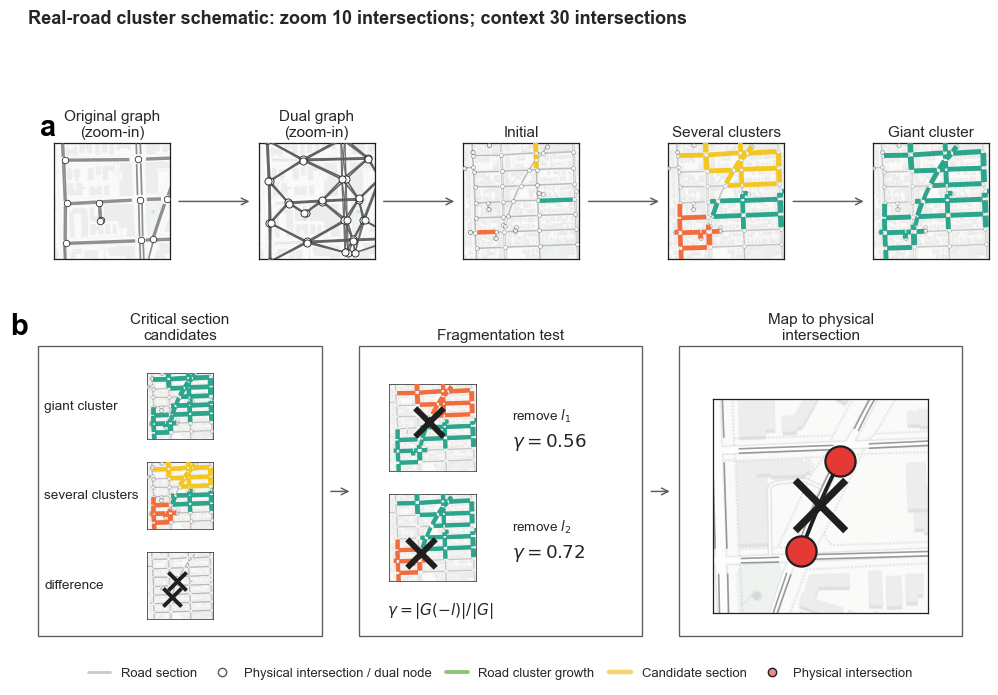

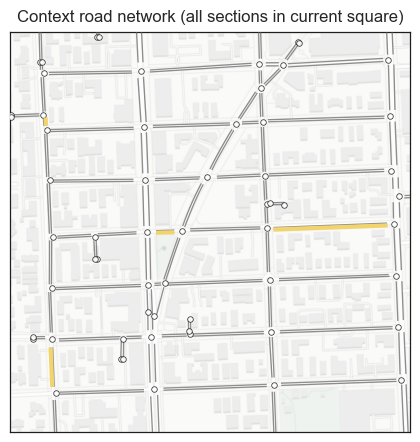

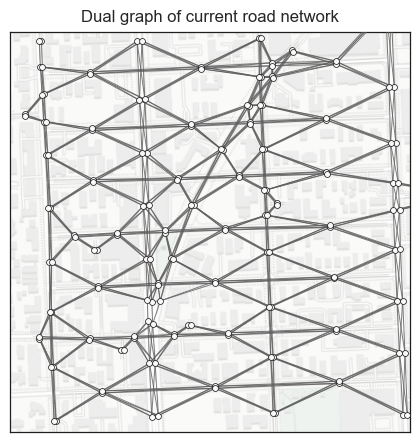

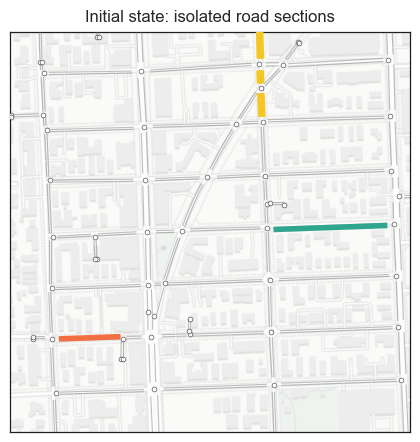

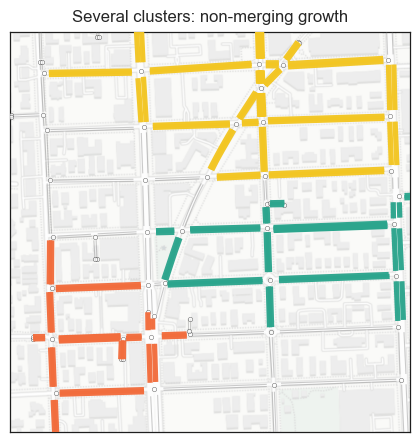

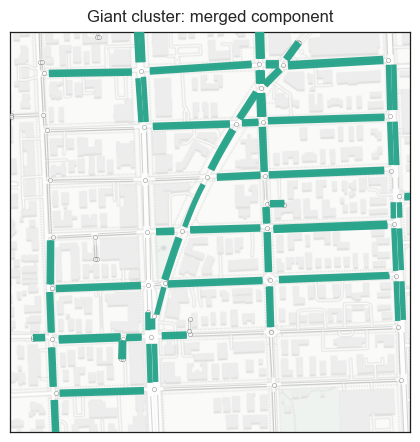

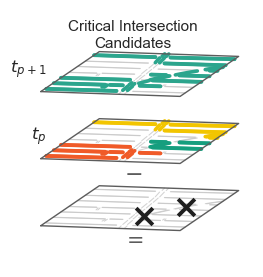

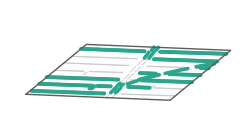

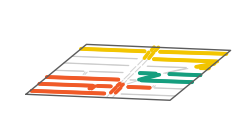

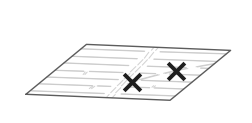

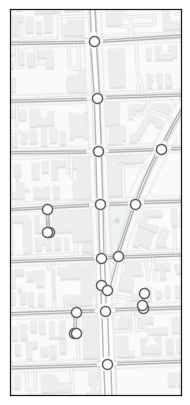

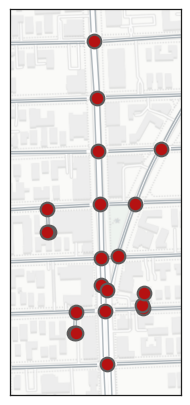

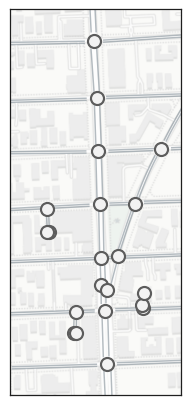

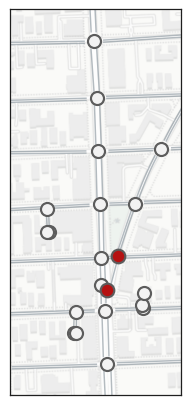

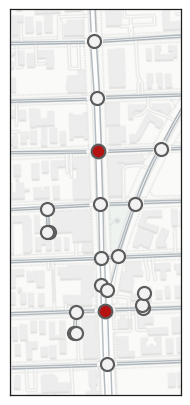

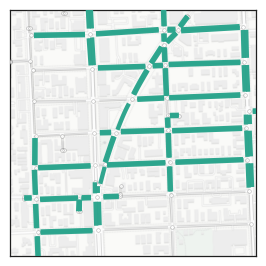

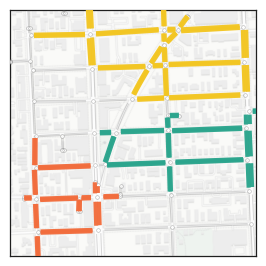

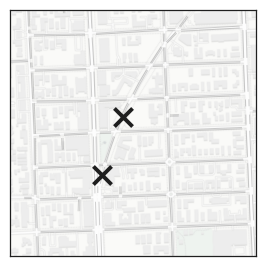

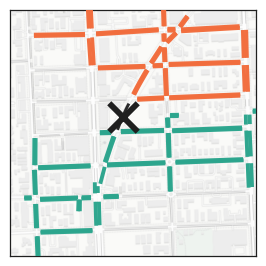

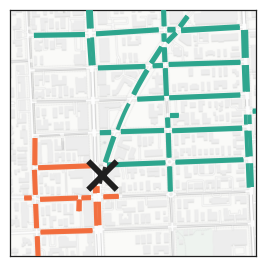

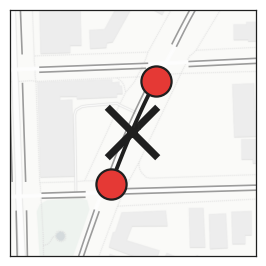

In [1]:

# Fig. 0: real-road-network schematic with a zoomed original-to-dual example
# Only this notebook contains new code; existing project code/data are read but not modified.

import sys
from pathlib import Path

import numpy as np
import geopandas as gpd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.patches import Rectangle, FancyArrowPatch, ConnectionPatch
from matplotlib.lines import Line2D
from shapely.geometry import Point, LineString, box

sys.path.insert(0, str(Path.cwd()))
import utils

PROJECT_DIR = Path('..').resolve()
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figure'
FIGURE_DIR.mkdir(exist_ok=True)

CENTER_NODE = 230858
ZOOM_RADIUS = 2      # 10 intersections, 20 road sections: original -> dual explanation
MACRO_RADIUS = 4     # map context: about 30 intersections, shown as colored road clusters

PALETTE = {
    'green': '#8CC576',
    'green_dark': '#2CA58D',
    'orange': '#F2A65A',
    'red': '#E88C8C',
    'yellow': '#F3D36B',
    'gray': '#C9C9C9',
    'light_gray': '#ECECEC',
    'dark_gray': '#5C5C5C',
    'black': '#1F1F1F',
    'blue': '#6E8FC7',
    'purple': '#B58AC8',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'font.size': 10.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 11.0,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'axes.linewidth': 0.9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})


def load_real_network():
    roads = gpd.read_file(DATA_DIR / 'external/aimsun_topo/section_edit.shp')
    roads = roads.rename(columns={'id': 'oid'}).copy()
    roads['oid'] = roads['oid'].astype(int)
    loader = utils.LoadData()
    G_primal, G_dual = loader.load_map_data(
        str(DATA_DIR / 'external/aimsun_topo/section_edit.shp'),
        str(DATA_DIR / 'external/aimsun_topo/nodes.shp'),
    )
    return roads, G_primal, G_dual


ROADS, G_PRIMAL, G_DUAL = load_real_network()
H_ZOOM = nx.ego_graph(G_PRIMAL, CENTER_NODE, radius=ZOOM_RADIUS, undirected=True).copy()
H_MACRO = nx.ego_graph(G_PRIMAL, CENTER_NODE, radius=MACRO_RADIUS, undirected=True).copy()


def edge_gdf_from_graph(H):
    rows = []
    for u, v, k, data in H.edges(data=True, keys=True):
        oid = int(data['name'])
        geom = ROADS.loc[ROADS['oid'] == oid, 'geometry'].iloc[0]
        rows.append({'u': u, 'v': v, 'k': k, 'oid': oid, 'geometry': geom})
    return gpd.GeoDataFrame(rows, geometry='geometry', crs=ROADS.crs)


def node_gdf_from_graph(H):
    rows = []
    for n, data in H.nodes(data=True):
        p = data['loc']
        rows.append({'node': n, 'geometry': Point(p.x, p.y)})
    return gpd.GeoDataFrame(rows, geometry='geometry', crs=ROADS.crs)


ZOOM_EDGES = edge_gdf_from_graph(H_ZOOM)
ZOOM_NODES = node_gdf_from_graph(H_ZOOM)
MACRO_EDGES = edge_gdf_from_graph(H_MACRO)
MACRO_NODES = node_gdf_from_graph(H_MACRO)
ZOOM_EDGE_IDS = list(ZOOM_EDGES['oid'].astype(int))
MACRO_EDGE_IDS = list(MACRO_EDGES['oid'].astype(int))


def square_bounds(gdf, pad_frac=0.16):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    side = max(xmax - xmin, ymax - ymin) * (1 + pad_frac)
    return (cx - side / 2, cx + side / 2, cy - side / 2, cy + side / 2)


ZOOM_BBOX = square_bounds(ZOOM_EDGES, pad_frac=0.18)
MACRO_BBOX = square_bounds(MACRO_EDGES, pad_frac=0.13)




def roads_within_bbox(bbox, pad=0):
    xmin, xmax, ymin, ymax = bbox
    return ROADS.cx[xmin - pad:xmax + pad, ymin - pad:ymax + pad].copy()

def nodes_within_bbox(bbox, pad=0):
    xmin, xmax, ymin, ymax = bbox
    rows = []
    for node, data in G_PRIMAL.nodes(data=True):
        p = data['loc']
        if xmin - pad <= p.x <= xmax + pad and ymin - pad <= p.y <= ymax + pad:
            rows.append({'node': node, 'geometry': Point(p.x, p.y)})
    return gpd.GeoDataFrame(rows, geometry='geometry', crs=ROADS.crs)

def choose_far_apart_dual_sections(edge_gdf, n=5, min_dual_distance=4):
    candidates = edge_gdf[edge_gdf['oid'].isin(G_DUAL.nodes)].copy()
    candidates = candidates[candidates.geometry.length > candidates.geometry.length.quantile(0.20)].copy()
    candidates['cx'] = candidates.geometry.centroid.x
    candidates['cy'] = candidates.geometry.centroid.y
    centroid = np.array([candidates['cx'].mean(), candidates['cy'].mean()])
    candidates['from_center'] = np.hypot(candidates['cx'] - centroid[0], candidates['cy'] - centroid[1])
    chosen = [int(candidates.sort_values('from_center', ascending=False).iloc[0]['oid'])]
    while len(chosen) < n:
        best_oid = None
        best_score = -np.inf
        for row in candidates.itertuples():
            oid = int(row.oid)
            if oid in chosen:
                continue
            dual_dists = []
            valid = True
            for selected in chosen:
                try:
                    d = nx.shortest_path_length(G_DUAL, oid, selected)
                except nx.NetworkXNoPath:
                    d = min_dual_distance + 3
                dual_dists.append(d)
                if d < min_dual_distance:
                    valid = False
                    break
            if not valid:
                continue
            spatial_dists = np.hypot(row.cx - candidates.set_index('oid').loc[chosen, 'cx'],
                                     row.cy - candidates.set_index('oid').loc[chosen, 'cy'])
            score = float(np.min(spatial_dists)) + 25.0 * float(np.min(dual_dists))
            if score > best_score:
                best_score = score
                best_oid = oid
        if best_oid is None:
            min_dual_distance = max(2, min_dual_distance - 1)
            continue
        chosen.append(best_oid)
    return chosen

def choose_composed_initial_sections(edge_gdf, min_dual_distance=4):
    candidates = edge_gdf[edge_gdf['oid'].isin(G_DUAL.nodes)].copy()
    candidates = candidates[candidates.geometry.length > candidates.geometry.length.quantile(0.25)].copy()
    candidates['cx'] = candidates.geometry.centroid.x
    candidates['cy'] = candidates.geometry.centroid.y
    bounds = candidates.geometry.bounds
    dx = bounds['maxx'] - bounds['minx']
    dy = bounds['maxy'] - bounds['miny']
    candidates['angle'] = np.degrees(np.arctan2(dy, dx))
    candidates['orientation'] = np.select(
        [candidates['angle'] <= 25, candidates['angle'] >= 65],
        ['horizontal', 'vertical'],
        default='diagonal',
    )
    center = np.array([candidates['cx'].mean(), candidates['cy'].mean()])
    candidates['from_center'] = np.hypot(candidates['cx'] - center[0], candidates['cy'] - center[1])

    chosen = []
    target_orientations = ['horizontal', 'vertical', 'diagonal']
    for orientation in target_orientations:
        pool = candidates[candidates['orientation'] == orientation].copy()
        if pool.empty:
            pool = candidates.copy()
        best_oid = None
        best_score = -np.inf
        for row in pool.itertuples():
            oid = int(row.oid)
            if oid in chosen:
                continue
            if chosen:
                dual_dists = []
                valid = True
                for selected in chosen:
                    try:
                        d = nx.shortest_path_length(G_DUAL, oid, selected)
                    except nx.NetworkXNoPath:
                        d = min_dual_distance + 3
                    dual_dists.append(d)
                    if d < min_dual_distance:
                        valid = False
                        break
                if not valid:
                    continue
                chosen_xy = candidates.set_index('oid').loc[chosen, ['cx', 'cy']].to_numpy()
                spatial_score = np.min(np.hypot(row.cx - chosen_xy[:, 0], row.cy - chosen_xy[:, 1]))
                dual_score = np.min(dual_dists)
            else:
                spatial_score = row.from_center
                dual_score = min_dual_distance
            score = float(spatial_score) + 30.0 * float(dual_score) + 0.35 * float(row.from_center)
            if score > best_score:
                best_score = score
                best_oid = oid
        if best_oid is not None:
            chosen.append(best_oid)

    if len(chosen) < 3:
        for oid in choose_far_apart_dual_sections(edge_gdf, n=3, min_dual_distance=3):
            if oid not in chosen:
                chosen.append(oid)
            if len(chosen) == 3:
                break
    return chosen[:3]

def choose_targeted_initial_sections(edge_gdf):
    xmin, xmax, ymin, ymax = MACRO_BBOX
    candidates = edge_gdf[edge_gdf['oid'].isin(G_DUAL.nodes)].copy()
    bounds = candidates.geometry.bounds
    dx = bounds['maxx'] - bounds['minx']
    dy = bounds['maxy'] - bounds['miny']
    candidates['angle'] = np.degrees(np.arctan2(dy, dx))
    targets = [
        # x fraction, y fraction, orientation, color role
        (0.67, 0.88, 'diagonal'),
        (0.82, 0.51, 'horizontal'),
        (0.18, 0.28, 'horizontal'),
    ]
    chosen = []
    for fx, fy, orientation in targets:
        point = Point(xmin + fx * (xmax - xmin), ymin + fy * (ymax - ymin))
        if orientation == 'horizontal':
            pool = candidates[candidates['angle'] <= 25].copy()
        elif orientation == 'vertical':
            pool = candidates[candidates['angle'] >= 65].copy()
        else:
            pool = candidates[(candidates['angle'] > 25) & (candidates['angle'] < 65)].copy()
        if pool.empty:
            pool = candidates.copy()
        pool['target_distance'] = pool.geometry.distance(point)
        for oid in pool.sort_values('target_distance')['oid'].astype(int):
            if oid not in chosen:
                chosen.append(oid)
                break
    return chosen

def choose_targeted_initial_groups(edge_gdf):
    xmin, xmax, ymin, ymax = MACRO_BBOX
    seed_ids = choose_targeted_initial_sections(edge_gdf)
    yellow_box = box(
        xmin + 0.585 * (xmax - xmin),
        ymin + 0.775 * (ymax - ymin),
        xmin + 0.655 * (xmax - xmin),
        ymin + 0.995 * (ymax - ymin),
    )
    candidates = edge_gdf[edge_gdf['oid'].isin(G_DUAL.nodes)].copy()
    yellow_candidates = candidates[candidates.geometry.intersects(yellow_box)].copy()
    yellow_bounds = yellow_candidates.geometry.bounds
    yellow_dx = yellow_bounds['maxx'] - yellow_bounds['minx']
    yellow_dy = yellow_bounds['maxy'] - yellow_bounds['miny']
    yellow_candidates['angle'] = np.degrees(np.arctan2(yellow_dy, yellow_dx))
    yellow_group = yellow_candidates[yellow_candidates['angle'] > 65]['oid'].astype(int).tolist()
    if not yellow_group:
        yellow_group = [seed_ids[0]]
    return [yellow_group, [seed_ids[1]], [seed_ids[2]]]

def flatten_groups(groups):
    return [int(oid) for group in groups for oid in group]

def normalize_seed_groups(seed_ids, available):
    groups = []
    for seed in seed_ids:
        if isinstance(seed, (list, tuple, set, np.ndarray)):
            group = {int(x) for x in seed if int(x) in available}
        else:
            group = {int(seed)} if int(seed) in available else set()
        if group:
            groups.append(group)
    return groups

def grow_non_merging_clusters(seed_ids, available_ids, steps=2):
    available = {int(x) for x in available_ids if int(x) in G_DUAL.nodes}
    groups = normalize_seed_groups(seed_ids, available)
    for _ in range(steps):
        occupied = set().union(*groups) if groups else set()
        additions = [set() for _ in groups]
        for i, group in enumerate(groups):
            other_groups = [groups[j] | additions[j] for j in range(len(groups)) if j != i]
            other_occupied = set().union(*other_groups) if other_groups else set()
            candidates = set()
            for oid in group:
                candidates.update(int(nb) for nb in G_DUAL.neighbors(oid) if int(nb) in available)
            candidates -= occupied
            candidates -= set().union(*additions) if additions else set()
            for cand in sorted(candidates):
                touches_other = any(int(nb) in other_occupied for nb in G_DUAL.neighbors(cand))
                if not touches_other:
                    additions[i].add(cand)
        for i, add in enumerate(additions):
            groups[i].update(add)
    return [sorted(group) for group in groups]

def grow_giant_cluster(seed_ids, available_ids, radius=3):
    available = {int(x) for x in available_ids if int(x) in G_DUAL.nodes}
    base_groups = grow_non_merging_clusters(seed_ids, available, steps=2)
    cluster = set().union(*[set(group) for group in base_groups])
    # The giant component is created by adding only the two missing bridges
    # between the previously separated clusters, not by expanding everywhere.
    bridge_pairs = [(base_groups[0], base_groups[1]), (base_groups[1], base_groups[2])]
    for group_a, group_b in bridge_pairs:
        best_path = None
        best_len = np.inf
        for a in group_a:
            for b in group_b:
                try:
                    path = nx.shortest_path(G_DUAL, int(a), int(b))
                except nx.NetworkXNoPath:
                    continue
                if len(path) < best_len:
                    best_len = len(path)
                    best_path = path
        if best_path is not None:
            cluster.update(int(x) for x in best_path if int(x) in available)
    return sorted(cluster)

def bridge_candidate_sections(seed_ids, available_ids):
    available = {int(x) for x in available_ids if int(x) in G_DUAL.nodes}
    base_groups = grow_non_merging_clusters(seed_ids, available, steps=2)
    base = set().union(*[set(group) for group in base_groups])
    bridge_ids = []
    for group_a, group_b in [(base_groups[0], base_groups[1]), (base_groups[1], base_groups[2])]:
        best_path = None
        best_len = np.inf
        for a in group_a:
            for b in group_b:
                try:
                    path = nx.shortest_path(G_DUAL, int(a), int(b))
                except nx.NetworkXNoPath:
                    continue
                if len(path) < best_len:
                    best_len = len(path)
                    best_path = path
        if best_path is not None:
            bridge_ids.extend(int(x) for x in best_path if int(x) in available and int(x) not in base)
    return sorted(set(bridge_ids))

def bounds_for_sections(edge_gdf, section_ids, pad_frac=0.45):
    subset = edge_gdf[edge_gdf['oid'].isin(section_ids)]
    if subset.empty:
        return ZOOM_BBOX
    return square_bounds(subset, pad_frac=pad_frac)

def endpoints_from_sections(edge_gdf, section_ids):
    points = []
    for geom in edge_gdf[edge_gdf['oid'].isin(section_ids)].geometry:
        coords = list(geom.coords)
        points.append(Point(coords[0]))
        points.append(Point(coords[-1]))
    return gpd.GeoDataFrame(geometry=points, crs=ROADS.crs)

def fragmented_components_after_removal(edge_gdf, remove_id):
    seed_groups = choose_targeted_initial_groups(edge_gdf)
    giant_ids = grow_giant_cluster(seed_groups, edge_gdf['oid'], radius=3)
    remaining = [int(oid) for oid in giant_ids if int(oid) != int(remove_id)]
    H = G_DUAL.subgraph(remaining).copy()
    components = [sorted(int(x) for x in comp) for comp in nx.connected_components(H)]
    components = sorted(components, key=len, reverse=True)
    gamma = len(components[0]) / max(1, len(giant_ids)) if components else 0.0
    return components, gamma

def draw_fragmented_after_removal(ax, remove_id, title=None):
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    components, gamma = fragmented_components_after_removal(all_context_roads, remove_id)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.70, alpha=0.22, zorder=2)
    component_colors = ['#2CA58D', '#F26D3D', '#F3C623', '#6E8FC7']
    for comp, color in zip(components, component_colors):
        all_context_roads[all_context_roads['oid'].isin(comp)].plot(
            ax=ax, color=color, linewidth=2.8, alpha=0.98, zorder=5
        )
    removed = all_context_roads[all_context_roads['oid'] == int(remove_id)]
    removed.plot(ax=ax, color=PALETTE['black'], linewidth=2.1, alpha=0.95, zorder=6)
    if not removed.empty:
        c = removed.geometry.iloc[0].centroid
        ax.scatter([c.x], [c.y], marker='x', s=420, linewidths=4.2, color=PALETTE['black'], zorder=8)
    if title:
        ax.set_title(title, pad=5)
    return gamma

def setup_square(ax, bbox):
    xmin, xmax, ymin, ymax = bbox
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.9)
        spine.set_color(PALETTE['black'])


def add_panel_label(ax, label, x=-0.12, y=1.02):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=21.0,
        fontfamily='Arial',
        fontweight='heavy',
        color='black',
        ha='left',
        va='bottom',
        clip_on=False,
    )



def add_safe_basemap(ax):
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=ROADS.crs, attribution=False)
    except Exception as exc:
        print(f"Basemap skipped: {type(exc).__name__}: {exc}")


def add_road_detail_basemap(ax):
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=ROADS.crs, attribution=False, zoom=18)
    except Exception as exc:
        print(f"Detailed basemap skipped: {type(exc).__name__}: {exc}")


def simple_graph_with_oids(edge_gdf, H):
    G = nx.Graph()
    G.add_nodes_from(H.nodes())
    for row in edge_gdf.itertuples():
        G.add_edge(row.u, row.v, oid=int(row.oid))
    return G


def dual_geometry(edge_gdf):
    pos = {int(row.oid): row.geometry.centroid for row in edge_gdf.itertuples()}
    edge_ids = set(pos)
    rows = []
    for u, v in G_DUAL.edges():
        u = int(u); v = int(v)
        if u in edge_ids and v in edge_ids:
            rows.append({'u': u, 'v': v, 'geometry': LineString([pos[u], pos[v]])})
    node_gdf = gpd.GeoDataFrame(
        {'oid': list(pos.keys())},
        geometry=[pos[k] for k in pos.keys()],
        crs=ROADS.crs,
    )
    edge_lines = gpd.GeoDataFrame(rows, geometry='geometry', crs=ROADS.crs)
    return node_gdf, edge_lines


ZOOM_DUAL_NODES, ZOOM_DUAL_EDGES = dual_geometry(ZOOM_EDGES)
MACRO_DUAL_NODES, MACRO_DUAL_EDGES = dual_geometry(MACRO_EDGES)


def choose_candidate_edges(edge_gdf, H, n=2):
    G = simple_graph_with_oids(edge_gdf, H)
    centrality = nx.edge_betweenness_centrality(G)
    chosen = sorted(centrality, key=centrality.get, reverse=True)[:n]
    return [int(G.edges[u, v]['oid']) for u, v in chosen]


def choose_spatial_seed_edges(edge_gdf, n=4):
    """Pick spatially separated seed road sections in the context map."""
    work = edge_gdf.copy()
    work['cx'] = work.geometry.centroid.x
    work['cy'] = work.geometry.centroid.y
    center = np.array([work['cx'].mean(), work['cy'].mean()])

    seeds = []
    # start from a peripheral edge, then greedily maximize distance from chosen seeds
    first = work.iloc[np.argmax(np.linalg.norm(work[['cx', 'cy']].to_numpy() - center, axis=1))]
    seeds.append(int(first['oid']))
    while len(seeds) < n:
        chosen_pts = work[work['oid'].isin(seeds)][['cx', 'cy']].to_numpy()
        remaining = work[~work['oid'].isin(seeds)].copy()
        pts = remaining[['cx', 'cy']].to_numpy()
        d = np.min(np.linalg.norm(pts[:, None, :] - chosen_pts[None, :, :], axis=2), axis=1)
        next_oid = int(remaining.iloc[int(np.argmax(d))]['oid'])
        seeds.append(next_oid)
    return seeds


def dual_neighborhood(edge_ids, radius=1):
    edge_ids = [int(x) for x in edge_ids if int(x) in G_DUAL.nodes]
    grown = set(edge_ids)
    for seed in edge_ids:
        grown.update(nx.single_source_shortest_path_length(G_DUAL, seed, cutoff=radius).keys())
    return [int(x) for x in grown if int(x) in set(MACRO_EDGE_IDS)]


def connect_groups(edge_groups):
    """Add shortest dual paths so separate groups visibly merge into one giant cluster."""
    merged = set().union(*[set(g) for g in edge_groups])
    anchors = [int(g[0]) for g in edge_groups if len(g) and int(g[0]) in G_DUAL.nodes]
    for a, b in zip(anchors[:-1], anchors[1:]):
        try:
            path = nx.shortest_path(G_DUAL, a, b)
            merged.update(int(x) for x in path if int(x) in set(MACRO_EDGE_IDS))
        except nx.NetworkXNoPath:
            pass
    return sorted(merged)


SEED_EDGE_IDS = choose_spatial_seed_edges(MACRO_EDGES, n=4)
INITIAL_GROUPS = [[oid] for oid in SEED_EDGE_IDS]
SEVERAL_GROUPS = [dual_neighborhood([oid], radius=1) for oid in SEED_EDGE_IDS]
GIANT_CLUSTER = connect_groups([dual_neighborhood([oid], radius=2) for oid in SEED_EDGE_IDS])
CANDIDATE_EDGE_IDS = sorted(set(GIANT_CLUSTER).difference(set().union(*[set(g) for g in SEVERAL_GROUPS])))[:2]
if not CANDIDATE_EDGE_IDS:
    CANDIDATE_EDGE_IDS = choose_candidate_edges(MACRO_EDGES, H_MACRO, n=2)


def road_color_map(state):
    cluster_colors = [PALETTE['red'], PALETTE['yellow'], PALETTE['blue'], PALETTE['green']]
    if state == 'none':
        mapping = {}
        for i, group in enumerate(INITIAL_GROUPS):
            for oid in group:
                mapping[oid] = cluster_colors[i % len(cluster_colors)]
        return mapping

    if state == 'small':
        mapping = {}
        for i, group in enumerate(SEVERAL_GROUPS):
            for oid in group:
                mapping[oid] = cluster_colors[i % len(cluster_colors)]
        return mapping

    if state == 'merged':
        return {oid: PALETTE['green_dark'] for oid in GIANT_CLUSTER}

    if state == 'fragmented':
        mapping = {}
        for i, group in enumerate(SEVERAL_GROUPS):
            for oid in group:
                mapping[oid] = cluster_colors[i % len(cluster_colors)]
        return mapping

    raise ValueError(state)


def draw_primal(ax, edge_gdf=ZOOM_EDGES, node_gdf=ZOOM_NODES, bbox=ZOOM_BBOX, title=None, highlight_zoom=True):
    setup_square(ax, bbox)
    edge_gdf.plot(ax=ax, color=PALETTE['gray'], linewidth=1.8, alpha=0.72, zorder=2)
    if highlight_zoom:
        edge_gdf[edge_gdf['oid'].isin(CANDIDATE_EDGE_IDS)].plot(ax=ax, color=PALETTE['yellow'], linewidth=3.3, zorder=4)
    node_gdf.plot(ax=ax, facecolor='white', edgecolor=PALETTE['dark_gray'], markersize=36, linewidth=0.85, zorder=5)
    if title:
        ax.set_title(title, pad=5)


def draw_dual(ax, title=None):
    setup_square(ax, ZOOM_BBOX)
    ZOOM_EDGES.plot(ax=ax, color='#E6E6E6', linewidth=0.8, alpha=0.80, zorder=1)
    if len(ZOOM_DUAL_EDGES):
        ZOOM_DUAL_EDGES.plot(ax=ax, color='#B8B8B8', linewidth=0.8, alpha=0.82, zorder=2)
    ZOOM_DUAL_NODES.plot(ax=ax, facecolor='white', edgecolor=PALETTE['dark_gray'], markersize=48, linewidth=0.85, zorder=3)
    ZOOM_DUAL_NODES[ZOOM_DUAL_NODES['oid'].isin(CANDIDATE_EDGE_IDS)].plot(
        ax=ax, facecolor=PALETTE['yellow'], edgecolor=PALETTE['black'], markersize=72, linewidth=1.0, zorder=4
    )
    if title:
        ax.set_title(title, pad=5)


def draw_context_original_zoom(ax, title=None):
    setup_square(ax, ZOOM_BBOX)
    add_safe_basemap(ax)
    zoom_roads = roads_within_bbox(ZOOM_BBOX)
    zoom_nodes = nodes_within_bbox(ZOOM_BBOX)
    zoom_roads.plot(ax=ax, color=PALETTE['dark_gray'], linewidth=1.25, alpha=0.68, zorder=3)
    zoom_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=22,
                    linewidth=0.58, alpha=0.95, zorder=4)
    if title:
        ax.set_title(title, pad=5)


def draw_context_dual_zoom(ax, title=None):
    setup_square(ax, ZOOM_BBOX)
    add_safe_basemap(ax)
    zoom_roads = roads_within_bbox(ZOOM_BBOX)
    dual_nodes, dual_edges = dual_geometry(zoom_roads)
    zoom_roads.plot(ax=ax, color='#BDBDBD', linewidth=0.82, alpha=0.36, zorder=2)
    if len(dual_edges):
        dual_edges.plot(ax=ax, color=PALETTE['dark_gray'], linewidth=0.95, alpha=0.82, zorder=3)
    dual_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=26,
                    linewidth=0.65, alpha=0.96, zorder=4)
    if title:
        ax.set_title(title, pad=5)


def draw_context_initial(ax, title=None):
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    seed_colors = ['#F3C623', '#2CA58D', '#F26D3D']
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.72, alpha=0.32, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=8,
                           linewidth=0.34, alpha=0.55, zorder=4)
    for group, color in zip(seed_groups, seed_colors):
        all_context_roads[all_context_roads['oid'].isin(group)].plot(
            ax=ax, color=color, linewidth=3.2, alpha=0.98, zorder=6
        )
    if title:
        ax.set_title(title, pad=5)


def draw_context_several(ax, title=None):
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    cluster_colors = ['#F3C623', '#2CA58D', '#F26D3D']
    groups = grow_non_merging_clusters(seed_groups, all_context_roads['oid'], steps=2)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.70, alpha=0.26, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=7,
                           linewidth=0.30, alpha=0.45, zorder=4)
    for group, color in zip(groups, cluster_colors):
        all_context_roads[all_context_roads['oid'].isin(group)].plot(
            ax=ax, color=color, linewidth=3.0, alpha=0.97, zorder=6
        )
    if title:
        ax.set_title(title, pad=5)


def draw_context_giant(ax, title=None):
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    giant_ids = grow_giant_cluster(seed_groups, all_context_roads['oid'], radius=3)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.70, alpha=0.24, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=7,
                           linewidth=0.30, alpha=0.42, zorder=4)
    all_context_roads[all_context_roads['oid'].isin(giant_ids)].plot(
        ax=ax, color=PALETTE['green_dark'], linewidth=3.1, alpha=0.98, zorder=6
    )
    if title:
        ax.set_title(title, pad=5)


def draw_bridge_candidate_zoom(ax, title=None):
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.72, alpha=0.30, zorder=2)
    bridges = all_context_roads[all_context_roads['oid'].isin(bridge_ids)]
    if not bridges.empty:
        centroids = bridges.geometry.centroid
        ax.scatter(centroids.x, centroids.y, marker='x', s=170, linewidths=2.8,
                   color=PALETTE['black'], zorder=7)
    if title:
        ax.set_title(title, pad=5)


def draw_cluster_state(ax, state, title=None):
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    # pale full physical network for context
    MACRO_EDGES.plot(ax=ax, color='#BDBDBD', linewidth=1.05, alpha=0.55, zorder=2)

    color_map = road_color_map(state)
    if color_map:
        active = MACRO_EDGES.copy()
        active['color'] = active['oid'].map(color_map)
        for color in active['color'].dropna().unique():
            active[active['color'] == color].plot(
                ax=ax, color=color, linewidth=2.35, alpha=0.98, zorder=4
            )

    if state in {'small', 'merged'}:
        MACRO_EDGES[MACRO_EDGES['oid'].isin(CANDIDATE_EDGE_IDS)].plot(
            ax=ax, color=PALETTE['yellow'], linewidth=3.2, alpha=0.98, zorder=6
        )
    xmin, xmax, ymin, ymax = ZOOM_BBOX
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False,
                           edgecolor=PALETTE['black'], linewidth=0.75, linestyle='--', zorder=8))
    if title:
        ax.set_title(title, pad=5)


def gamma_without_candidate():
    total = max(1, len(MACRO_EDGE_IDS))
    largest = max((len(group) for group in SEVERAL_GROUPS), default=0)
    return largest / total


GAMMA_REMOVED = gamma_without_candidate()


def draw_candidate_layers(ax):
    ax.set_axis_off()
    layers = [('giant cluster', draw_context_giant), ('several clusters', draw_context_several), ('difference', draw_bridge_candidate_zoom)]
    for i, (label, drawer) in enumerate(layers):
        y = 0.68 - i * 0.31
        iax = ax.inset_axes([0.10, y, 0.80, 0.23])
        drawer(iax)
        for spine in iax.spines.values():
            spine.set_linewidth(0.50)
        ax.text(0.02, y + 0.115, label, transform=ax.transAxes, fontsize=9.8, ha='left', va='center')
    ax.set_title('Critical section\ncandidates', pad=5)


def draw_fragmentation_test(ax):
    ax.set_axis_off()
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])[:2]
    for i, remove_id in enumerate(bridge_ids):
        y = 0.57 - i * 0.38
        iax = ax.inset_axes([0.06, y, 0.40, 0.30])
        gamma = draw_fragmented_after_removal(iax, remove_id)
        for spine in iax.spines.values():
            spine.set_linewidth(0.50)
        ax.text(0.54, y + 0.19, rf'remove $l_{i + 1}$', transform=ax.transAxes, fontsize=9.7, ha='left', va='center')
        ax.text(0.54, y + 0.10, rf'$\gamma={gamma:.2f}$', transform=ax.transAxes, fontsize=13.2, ha='left', va='center')
    ax.text(0.10, 0.09, r'$\gamma=|G(-l)|/|G|$', transform=ax.transAxes, fontsize=11.0, ha='left', va='center')
    ax.set_title('Fragmentation test', pad=5)


def candidate_endpoint_nodes():
    endpoints = set()
    for row in MACRO_EDGES[MACRO_EDGES['oid'].isin(CANDIDATE_EDGE_IDS)].itertuples():
        endpoints.add(row.u)
        endpoints.add(row.v)
    return list(endpoints)


def draw_map_to_intersection(ax):
    ax.set_axis_off()
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
    selected_id = bridge_ids[0]
    selected = all_context_roads[all_context_roads['oid'] == selected_id]

    bottom = ax.inset_axes([0.10, 0.08, 0.80, 0.74])
    bridge_bbox = bounds_for_sections(all_context_roads, [selected_id], pad_frac=1.40)
    setup_square(bottom, bridge_bbox)
    add_road_detail_basemap(bottom)
    local_roads = roads_within_bbox(bridge_bbox)
    local_roads.plot(ax=bottom, color='#777777', linewidth=1.18, alpha=0.72, zorder=2)
    selected.plot(
        ax=bottom, color=PALETTE['black'], linewidth=2.8, zorder=5
    )
    endpoints = endpoints_from_sections(all_context_roads, [selected_id])
    endpoints.plot(ax=bottom, facecolor='#E53935', edgecolor=PALETTE['black'], markersize=472, linewidth=1.60, zorder=7)
    if not selected.empty:
        c = selected.geometry.iloc[0].centroid
        bottom.scatter([c.x], [c.y], marker='x', s=1320, linewidths=5.2, color=PALETTE['black'], zorder=8)
        bottom.text(c.x, c.y, r'$l_1$', fontsize=9.2, fontweight='bold', ha='left', va='bottom', zorder=9)
    ax.set_title('Map to physical\nintersection', pad=5)


def add_arrow_between(fig, ax_from, ax_to):
    b1 = ax_from.get_position()
    b2 = ax_to.get_position()
    start = (b1.x1 + 0.006, (b1.y0 + b1.y1) / 2)
    end = (b2.x0 - 0.006, (b2.y0 + b2.y1) / 2)
    fig.add_artist(FancyArrowPatch(start, end, transform=fig.transFigure,
                                   arrowstyle='->', mutation_scale=12, linewidth=1.05,
                                   color=PALETTE['dark_gray']))


def generate_fig0_panel(save_pdf='../figure/fig0_panel.pdf', save_png='../figure/fig0_panel.png'):
    fig = plt.figure(figsize=(10.5, 7.25), facecolor='white')

    top_y = 0.61
    size = 0.16
    xs = [0.050, 0.245, 0.440, 0.635, 0.830]
    ax_primal = fig.add_axes([xs[0], top_y, size, size])
    ax_dual = fig.add_axes([xs[1], top_y, size, size])
    state_axes = [fig.add_axes([x, top_y, size, size]) for x in xs[2:]]

    draw_context_original_zoom(ax_primal, title='Original graph\n(zoom-in)')
    draw_context_dual_zoom(ax_dual, title='Dual graph\n(zoom-in)')
    for ax, drawer, title in zip(
        state_axes,
        [draw_context_initial, draw_context_several, draw_context_giant],
        ['Initial', 'Several clusters', 'Giant cluster'],
    ):
        drawer(ax, title=title)

    add_panel_label(ax_primal, 'a')
    for left, right in zip([ax_primal, ax_dual] + state_axes[:-1], [ax_dual] + state_axes):
        add_arrow_between(fig, left, right)

    box_y = 0.09
    box_h = 0.40
    box_w = 0.27
    ax_candidates = fig.add_axes([0.060, box_y, box_w, box_h])
    ax_frag = fig.add_axes([0.365, box_y, box_w, box_h])
    ax_map = fig.add_axes([0.670, box_y, box_w, box_h])
    for ax in [ax_candidates, ax_frag, ax_map]:
        ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                               linewidth=0.95, edgecolor=PALETTE['dark_gray'], clip_on=False))

    draw_candidate_layers(ax_candidates)
    draw_fragmentation_test(ax_frag)
    draw_map_to_intersection(ax_map)
    add_panel_label(ax_candidates, 'b', x=-0.10, y=1.02)
    add_arrow_between(fig, ax_candidates, ax_frag)
    add_arrow_between(fig, ax_frag, ax_map)

    fig.text(0.050, 0.955,
             f'Real-road cluster schematic: zoom {H_ZOOM.number_of_nodes()} intersections; context {H_MACRO.number_of_nodes()} intersections',
             fontsize=13.0, fontweight='bold', ha='left', va='top')

    legend_handles = [
        Line2D([0], [0], color=PALETTE['gray'], lw=2.0, label='Road section'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=PALETTE['dark_gray'], label='Physical intersection / dual node'),
        Line2D([0], [0], color=PALETTE['green'], lw=2.8, label='Road cluster growth'),
        Line2D([0], [0], color=PALETTE['yellow'], lw=3.2, label='Candidate section'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE['red'], markeredgecolor=PALETTE['black'], label='Physical intersection'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.014),
               ncol=5, frameon=False, fontsize=9.4, handlelength=1.7, columnspacing=1.1)

    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


generate_fig0_panel()



def generate_fig0_context_network_preview(
    save_pdf='../figure/fig0_context_network.pdf',
    save_png='../figure/fig0_context_network.png',
):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='white')
    setup_square(ax, MACRO_BBOX)
    add_road_detail_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    all_context_roads.plot(ax=ax, color=PALETTE['dark_gray'], linewidth=0.95, alpha=0.68, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=16,
                           linewidth=0.55, alpha=0.92, zorder=4)
    MACRO_EDGES[MACRO_EDGES['oid'].isin(SEED_EDGE_IDS)].plot(ax=ax, color=PALETTE['yellow'], linewidth=3.0, zorder=5)
    ax.set_title(
        f'Context road network (all sections in current square)',
        fontsize=12,
        pad=7,
    )
    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_context_dual_preview(
    save_pdf='../figure/fig0_context_dual_graph.pdf',
    save_png='../figure/fig0_context_dual_graph.png',
):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='white')
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    dual_nodes, dual_edges = dual_geometry(all_context_roads)
    all_context_roads.plot(ax=ax, color='#BDBDBD', linewidth=0.72, alpha=0.42, zorder=2)
    if len(dual_edges):
        dual_edges.plot(ax=ax, color=PALETTE['dark_gray'], linewidth=0.72, alpha=0.78, zorder=3)
    dual_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=18,
                    linewidth=0.58, alpha=0.96, zorder=4)
    ax.set_title(
        f'Dual graph of current road network',
        fontsize=12,
        pad=7,
    )
    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_initial_sections_preview(
    save_pdf='../figure/fig0_initial_sections.pdf',
    save_png='../figure/fig0_initial_sections.png',
):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='white')
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    initial_groups = choose_targeted_initial_groups(all_context_roads)
    initial_colors = ['#F3C623', '#2CA58D', '#F26D3D']
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.82, alpha=0.42, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=12,
                           linewidth=0.45, alpha=0.82, zorder=4)
    for group, color in zip(initial_groups, initial_colors):
        all_context_roads[all_context_roads['oid'].isin(group)].plot(
            ax=ax, color=color, linewidth=4.0, alpha=0.98, zorder=6
        )
    ax.set_title(
        f'Initial state: isolated road sections',
        fontsize=12,
        pad=7,
    )
    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_several_clusters_preview(
    save_pdf='../figure/fig0_several_clusters.pdf',
    save_png='../figure/fig0_several_clusters.png',
):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='white')
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    cluster_colors = ['#F3C623', '#2CA58D', '#F26D3D']
    groups = grow_non_merging_clusters(seed_groups, all_context_roads['oid'], steps=2)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.78, alpha=0.34, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=10,
                           linewidth=0.38, alpha=0.65, zorder=4)
    for group, color in zip(groups, cluster_colors):
        all_context_roads[all_context_roads['oid'].isin(group)].plot(
            ax=ax, color=color, linewidth=3.8, alpha=0.97, zorder=6
        )
    for group, color in zip(seed_groups, cluster_colors):
        all_context_roads[all_context_roads['oid'].isin(group)].plot(
            ax=ax, color=color, linewidth=5.2, alpha=1.0, zorder=7
        )
    ax.set_title(
        f'Several clusters: non-merging growth',
        fontsize=12,
        pad=7,
    )
    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_giant_cluster_preview(
    save_pdf='../figure/fig0_giant_cluster.pdf',
    save_png='../figure/fig0_giant_cluster.png',
):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='white')
    setup_square(ax, MACRO_BBOX)
    add_safe_basemap(ax)
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    all_context_nodes = nodes_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    giant_ids = grow_giant_cluster(seed_groups, all_context_roads['oid'], radius=3)
    all_context_roads.plot(ax=ax, color='#6A6A6A', linewidth=0.74, alpha=0.28, zorder=3)
    all_context_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['black'], markersize=9,
                           linewidth=0.35, alpha=0.52, zorder=4)
    all_context_roads[all_context_roads['oid'].isin(giant_ids)].plot(
        ax=ax, color=PALETTE['green_dark'], linewidth=3.9, alpha=0.98, zorder=6
    )
    all_context_roads[all_context_roads['oid'].isin(flatten_groups(seed_groups))].plot(
        ax=ax, color=PALETTE['green_dark'], linewidth=5.2, alpha=1.0, zorder=7
    )
    ax.set_title(
        f'Giant cluster: merged component',
        fontsize=12,
        pad=7,
    )
    fig.savefig(save_pdf, dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(save_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def draw_l1_intersection_zoom(ax, title=None):
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
    selected_id = bridge_ids[0]
    selected = all_context_roads[all_context_roads['oid'] == selected_id]
    bridge_bbox = bounds_for_sections(all_context_roads, [selected_id], pad_frac=1.40)
    setup_square(ax, bridge_bbox)
    add_safe_basemap(ax)
    local_roads = roads_within_bbox(bridge_bbox)
    local_roads.plot(ax=ax, color='#777777', linewidth=1.18, alpha=0.72, zorder=2)
    selected.plot(ax=ax, color=PALETTE['black'], linewidth=2.8, zorder=5)
    endpoints = endpoints_from_sections(all_context_roads, [selected_id])
    endpoints.plot(ax=ax, facecolor='#E53935', edgecolor=PALETTE['black'], markersize=472,
                   linewidth=1.60, zorder=7)
    if not selected.empty:
        c = selected.geometry.iloc[0].centroid
        ax.scatter([c.x], [c.y], marker='x', s=1320, linewidths=5.2, color=PALETTE['black'], zorder=8)
        ax.text(c.x, c.y, r'$l_1$', fontsize=9.2, fontweight='bold', ha='left', va='bottom', zorder=9)
    if title:
        ax.set_title(title, pad=5)


def save_square_panel(drawer, filename, figsize=(3.2, 3.2), title=None, show=False):
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    if title is None:
        drawer(ax)
    else:
        drawer(ax, title=title)
    fig.savefig(FIGURE_DIR / filename, dpi=450, bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    plt.close(fig)


def transform_layer_coords(xs, ys, bbox, x0, y0, w, h, skew=0.42, x_shift=-0.18, y_tilt=-0.12):
    xmin, xmax, ymin, ymax = bbox
    xn = (np.asarray(xs) - xmin) / (xmax - xmin)
    yn = (np.asarray(ys) - ymin) / (ymax - ymin)
    return x0 + w * (xn + x_shift + skew * yn), y0 + h * (yn + y_tilt * xn)


def clip_edges_to_bbox(edge_gdf, bbox):
    xmin, xmax, ymin, ymax = bbox
    clip_box = box(xmin, ymin, xmax, ymax)
    clipped = edge_gdf.copy()
    clipped['geometry'] = clipped.geometry.intersection(clip_box)
    clipped = clipped[~clipped.geometry.is_empty & clipped.geometry.notna()].copy()
    return clipped


def tilted_layer_bbox():
    xmin, xmax, ymin, ymax = MACRO_BBOX
    return (
        xmin + 0.12 * (xmax - xmin),
        xmin + 0.54 * (xmax - xmin),
        ymin + 0.03 * (ymax - ymin),
        ymin + 0.98 * (ymax - ymin),
    )


def selected_vertical_strip_bbox():
    xmin, xmax, ymin, ymax = MACRO_BBOX
    return (
        xmin + 0.12 * (xmax - xmin),
        xmin + 0.54 * (xmax - xmin),
        ymin + 0.03 * (ymax - ymin),
        ymin + 0.98 * (ymax - ymin),
    )


def draw_tilted_network_layer(ax, edge_gdf, bbox, x0, y0, w, h, active_groups=None,
                              active_colors=None, x_sections=None, label=None, draw_label=True):
    skew = 0.42
    edge_gdf = clip_edges_to_bbox(edge_gdf, bbox)
    x_shift = -0.18
    y_tilt = -0.12
    corners_x = [x_shift, 1 + x_shift, 1 + x_shift + skew, x_shift + skew, x_shift]
    corners_y = [0, y_tilt, 1 + y_tilt, 1, 0]
    plane_x = x0 + w * np.asarray(corners_x)
    plane_y = y0 + h * np.asarray(corners_y)
    ax.fill(plane_x, plane_y, color='white', alpha=1.0, zorder=0)

    for geom in edge_gdf.geometry:
        geoms = list(geom.geoms) if hasattr(geom, 'geoms') else [geom]
        for part in geoms:
            coords = np.asarray(part.coords)
            xs, ys = transform_layer_coords(coords[:, 0], coords[:, 1], bbox, x0, y0, w, h, skew, x_shift=x_shift, y_tilt=y_tilt)
            ax.plot(xs, ys, color='#C8C8C8', linewidth=0.75, alpha=0.80, zorder=2)

    if active_groups and active_colors:
        for group, color in zip(active_groups, active_colors):
            for geom in edge_gdf[edge_gdf['oid'].isin(group)].geometry:
                geoms = list(geom.geoms) if hasattr(geom, 'geoms') else [geom]
                for part in geoms:
                    coords = np.asarray(part.coords)
                    xs, ys = transform_layer_coords(coords[:, 0], coords[:, 1], bbox, x0, y0, w, h, skew, x_shift=x_shift, y_tilt=y_tilt)
                    ax.plot(xs, ys, color=color, linewidth=2.6, alpha=1.0, zorder=4)

    if x_sections:
        bridges = edge_gdf[edge_gdf['oid'].isin(x_sections)]
        for geom in bridges.geometry:
            c = geom.centroid
            xs, ys = transform_layer_coords([c.x], [c.y], bbox, x0, y0, w, h, skew, x_shift=x_shift, y_tilt=y_tilt)
            ax.scatter(xs, ys, marker='x', s=145, linewidths=2.8, color=PALETTE['black'], zorder=5)

    ax.plot(plane_x, plane_y, color=PALETTE['dark_gray'], linewidth=1.0, zorder=8)

    if label and draw_label:
        ax.text(x0 - 0.08, y0 + h * 0.58, label, fontsize=12.0,
                fontstyle='italic', ha='right', va='center')


def save_tilted_candidate_layer(filename, layer):
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    several_groups = grow_non_merging_clusters(seed_groups, all_context_roads['oid'], steps=2)
    giant_ids = grow_giant_cluster(seed_groups, all_context_roads['oid'], radius=3)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
    colors = ['#F2C500', '#159E7E', '#F05A28']
    layer_bbox = tilted_layer_bbox()
    fig, ax = plt.subplots(figsize=(3.0, 1.35), facecolor='white')
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if layer == 'giant':
        draw_tilted_network_layer(ax, all_context_roads, layer_bbox, 0.18, 0.18, 0.62, 0.48,
                                  active_groups=[giant_ids], active_colors=[PALETTE['green_dark']],
                                  draw_label=False)
    elif layer == 'several':
        draw_tilted_network_layer(ax, all_context_roads, layer_bbox, 0.18, 0.18, 0.62, 0.48,
                                  active_groups=several_groups, active_colors=colors,
                                  draw_label=False)
    elif layer == 'difference':
        draw_tilted_network_layer(ax, all_context_roads, layer_bbox, 0.18, 0.18, 0.62, 0.48,
                                  x_sections=bridge_ids, draw_label=False)
    fig.savefig(FIGURE_DIR / filename, dpi=450, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_b_critical_candidates_layers(
    save_png='../figure/fig0_b_critical_candidates_layers.png',
):
    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    several_groups = grow_non_merging_clusters(seed_groups, all_context_roads['oid'], steps=2)
    giant_ids = grow_giant_cluster(seed_groups, all_context_roads['oid'], radius=3)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
    colors = ['#F2C500', '#159E7E', '#F05A28']
    layer_bbox = tilted_layer_bbox()

    fig, ax = plt.subplots(figsize=(3.1, 3.35), facecolor='white')
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.50, 0.96, 'Critical Intersection\nCandidates', fontsize=11.0,
            ha='center', va='top')

    x0, w, h = 0.22, 0.58, 0.155
    draw_tilted_network_layer(ax, all_context_roads, layer_bbox, x0, 0.68, w, h,
                              active_groups=[giant_ids], active_colors=[PALETTE['green_dark']],
                              label=r'$t_{p+1}$')
    draw_tilted_network_layer(ax, all_context_roads, layer_bbox, x0, 0.42, w, h,
                              active_groups=several_groups, active_colors=colors,
                              label=r'$t_p$')
    draw_tilted_network_layer(ax, all_context_roads, layer_bbox, x0, 0.16, w, h,
                              x_sections=bridge_ids)

    ax.text(0.50, 0.37, r'$-$', fontsize=16, ha='center', va='center', color=PALETTE['dark_gray'])
    ax.text(0.50, 0.11, r'$=$', fontsize=15, ha='center', va='center', color=PALETTE['dark_gray'])
    fig.savefig(FIGURE_DIR / Path(save_png).name, dpi=450, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_b_critical_candidate_layer_pngs():
    save_tilted_candidate_layer('fig0_b_layer_giant.png', 'giant')
    save_tilted_candidate_layer('fig0_b_layer_several.png', 'several')
    save_tilted_candidate_layer('fig0_b_layer_difference.png', 'difference')


def generate_fig0_selected_vertical_strip(
    save_png='../figure/fig0_selected_vertical_strip.png',
):
    bbox = selected_vertical_strip_bbox()
    xmin, xmax, ymin, ymax = bbox
    fig, ax = plt.subplots(figsize=(2.2, 5.1), facecolor='white')
    setup_square(ax, bbox)
    add_safe_basemap(ax)
    strip_roads = roads_within_bbox(bbox)
    strip_nodes = nodes_within_bbox(bbox)
    strip_roads.plot(ax=ax, color='#87939B', linewidth=1.05, alpha=0.62, zorder=2)
    strip_nodes.plot(ax=ax, facecolor='white', edgecolor=PALETTE['dark_gray'], markersize=52,
                     linewidth=1.05, alpha=0.98, zorder=4)
    fig.savefig(FIGURE_DIR / Path(save_png).name, dpi=450, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def strip_nodes_with_highlight(case='all_red'):
    bbox = selected_vertical_strip_bbox()
    strip_nodes = nodes_within_bbox(bbox).copy()
    strip_nodes['highlight'] = False
    if case == 'all_red':
        strip_nodes['highlight'] = True
    elif case == 'all_gray':
        strip_nodes['highlight'] = False
    elif case == 'critical_l2':
        all_context_roads = roads_within_bbox(MACRO_BBOX)
        seed_groups = choose_targeted_initial_groups(all_context_roads)
        bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])
        selected_id = bridge_ids[1] if len(bridge_ids) > 1 else bridge_ids[0]
        endpoints = endpoints_from_sections(all_context_roads, [selected_id])
        if not endpoints.empty and not strip_nodes.empty:
            endpoint_union = endpoints.geometry.union_all()
            strip_nodes['endpoint_distance'] = strip_nodes.geometry.distance(endpoint_union)
            highlight_ids = strip_nodes.nsmallest(2, 'endpoint_distance')['node'].tolist()
            strip_nodes['highlight'] = strip_nodes['node'].isin(highlight_ids)
    elif case == 'random_two':
        if len(strip_nodes) >= 2:
            rng = np.random.default_rng(42)
            first = rng.choice(strip_nodes['node'].to_numpy())
            first_geom = strip_nodes.loc[strip_nodes['node'] == first, 'geometry'].iloc[0]
            remaining = strip_nodes[strip_nodes['node'] != first].copy()
            remaining['distance_to_first'] = remaining.geometry.distance(first_geom)
            far_pool = remaining.nlargest(min(5, len(remaining)), 'distance_to_first')
            second = rng.choice(far_pool['node'].to_numpy())
            highlight_ids = [first, second]
            strip_nodes['highlight'] = strip_nodes['node'].isin(highlight_ids)
    else:
        raise ValueError(case)
    return strip_nodes


def generate_fig0_vertical_strip_signal_case(case, filename):
    bbox = selected_vertical_strip_bbox()
    fig, ax = plt.subplots(figsize=(2.2, 5.1), facecolor='white')
    setup_square(ax, bbox)
    add_safe_basemap(ax)
    strip_roads = roads_within_bbox(bbox)
    strip_nodes = strip_nodes_with_highlight(case)
    strip_roads.plot(ax=ax, color='#87939B', linewidth=1.05, alpha=0.62, zorder=2)
    gray_nodes = strip_nodes[~strip_nodes['highlight']]
    red_nodes = strip_nodes[strip_nodes['highlight']]
    if not gray_nodes.empty:
        gray_nodes.plot(ax=ax, facecolor='#F2F2F2', edgecolor=PALETTE['dark_gray'], markersize=88,
                        linewidth=1.55, alpha=1.0, zorder=4)
    if not red_nodes.empty:
        red_nodes.plot(ax=ax, facecolor='#B51212', edgecolor=PALETTE['dark_gray'], markersize=96,
                       linewidth=1.55, alpha=1.0, zorder=5)
    fig.savefig(FIGURE_DIR / filename, dpi=450, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


def generate_fig0_vertical_strip_signal_cases():
    generate_fig0_vertical_strip_signal_case('all_red', 'fig0_vertical_strip_all_red.png')
    generate_fig0_vertical_strip_signal_case('all_gray', 'fig0_vertical_strip_all_gray.png')
    generate_fig0_vertical_strip_signal_case('critical_l2', 'fig0_vertical_strip_critical_l2.png')
    generate_fig0_vertical_strip_signal_case('random_two', 'fig0_vertical_strip_random_two.png')


def generate_all_fig0_square_pngs():
    save_square_panel(draw_context_original_zoom, 'fig0_square_a1_original_graph.png')
    save_square_panel(draw_context_dual_zoom, 'fig0_square_a2_dual_graph.png')
    save_square_panel(draw_context_initial, 'fig0_square_a3_initial.png')
    save_square_panel(draw_context_several, 'fig0_square_a4_several_clusters.png')
    save_square_panel(draw_context_giant, 'fig0_square_a5_giant_cluster.png')
    save_square_panel(draw_context_giant, 'fig0_square_b1_critical_candidates_giant.png', show=True)
    save_square_panel(draw_context_several, 'fig0_square_b2_critical_candidates_several.png', show=True)
    save_square_panel(draw_bridge_candidate_zoom, 'fig0_square_b3_critical_candidates_difference.png', show=True)

    all_context_roads = roads_within_bbox(MACRO_BBOX)
    seed_groups = choose_targeted_initial_groups(all_context_roads)
    bridge_ids = bridge_candidate_sections(seed_groups, all_context_roads['oid'])[:2]
    for i, remove_id in enumerate(bridge_ids, start=1):
        save_square_panel(lambda ax, rid=remove_id: draw_fragmented_after_removal(ax, rid),
                          f'fig0_square_b4_fragmentation_remove_l{i}.png', show=True)
    save_square_panel(draw_l1_intersection_zoom, 'fig0_square_b5_section_to_intersections.png', show=True)


generate_fig0_context_network_preview()
generate_fig0_context_dual_preview()
generate_fig0_initial_sections_preview()
generate_fig0_several_clusters_preview()
generate_fig0_giant_cluster_preview()
generate_fig0_b_critical_candidates_layers()
generate_fig0_b_critical_candidate_layer_pngs()
generate_fig0_selected_vertical_strip()
generate_fig0_vertical_strip_signal_cases()
generate_all_fig0_square_pngs()
